# EN3160 Assignment 1
## Intensity Transformations and Neighborhood Filtering

---

**Prepared by:** Palihena H.H.  
**Index Number:** 230458P  
**GitHub Repository:** https://github.com/hivirup/EN3160-Assignment-1  

---

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# This line ensures your plots show up directly inside the notebook
%matplotlib inline

## Question 1: Piecewise Linear Transformations
In this section, we implement a piecewise linear intensity transformation. Using `numpy.interp` to generate a Lookup Table (LUT), we map input pixel intensities to new output values based on custom breakpoints. An "S-curve" is applied here to enhance the mid-tone contrast of the original image.

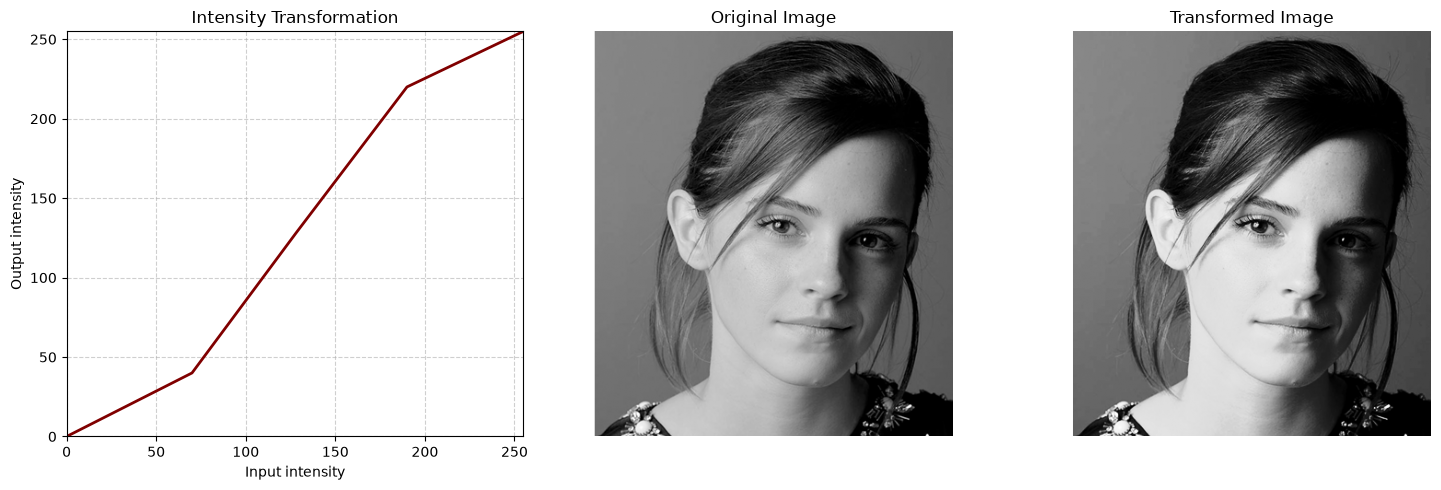

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def intensity_transform(im, breakpoints):
    """
    Applies a piecewise linear intensity transformation to an image.
    """
    # Convert breakpoints to a numpy array for easy slicing
    breakpoints = np.array(breakpoints)
    x_coords = breakpoints[:, 0]
    y_coords = breakpoints[:, 1]
    
    # Create an array for all possible 256 input pixel values (0 to 255)
    x_vals = np.arange(256)
    
    # Use linear interpolation to calculate the corresponding output for every possible input
    # This creates a Lookup Table (LUT)
    lut = np.interp(x_vals, x_coords, y_coords).astype(np.uint8)
    
    # Apply the lookup table to the image efficiently using OpenCV
    transformed_im = cv2.LUT(im, lut)
    
    return transformed_im

# 1. Define the breakpoints based on Figure 1a (using 1-pixel offsets for vertical jumps)
breakpoints= [
    [0, 0],
    [70, 40],    # Pulls down the shadows (makes hair and dress richer)
    [128, 128],  # Anchors the exact middle gray so the image doesn't get too dark/light
    [190, 220],  # Pushes up the highlights (brightens the skin and eye reflections)
    [255, 255]   # Keeps pure white as pure white
]

# 2. Load the original image (Figure 1b) in grayscale
# MAKE SURE to change 'image_1b.png' to the exact filename of the provided image!
img = cv2.imread('Emma.png', cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error: Could not load the image. Please check the filename and ensure it is in the same folder as this notebook.")
else:
    # 3. Apply the intensity transformation
    transformed_img = intensity_transform(img, breakpoints)
    
    # 4. Display the results side-by-side
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    
    # Plot the intensity transformation curve
    bp_array = np.array(breakpoints)
    axs[0].plot(bp_array[:, 0], bp_array[:, 1], color='maroon', linewidth=2)
    axs[0].set_title('Intensity Transformation')
    axs[0].set_xlabel('Input intensity')
    axs[0].set_ylabel('Output intensity')
    axs[0].set_xlim([0, 255])
    axs[0].set_ylim([0, 255])
    axs[0].grid(True, linestyle='--', alpha=0.6)
    
    # Plot the original image
    axs[1].imshow(img, cmap='gray', vmin=0, vmax=255)
    axs[1].set_title('Original Image')
    axs[1].axis('off')
    
    # Plot the transformed image
    axs[2].imshow(transformed_img, cmap='gray', vmin=0, vmax=255)
    axs[2].set_title('Transformed Image')
    axs[2].axis('off')
    
    plt.tight_layout()
    plt.show()

## Question 2: Targeted Intensity Mapping
Here, we apply the custom intensity transformation function to a proton density brain MRI. By adjusting the breakpoints to target specific narrow intensity ranges (a technique known as windowing), we visually isolate and accentuate the white matter and gray matter structures.

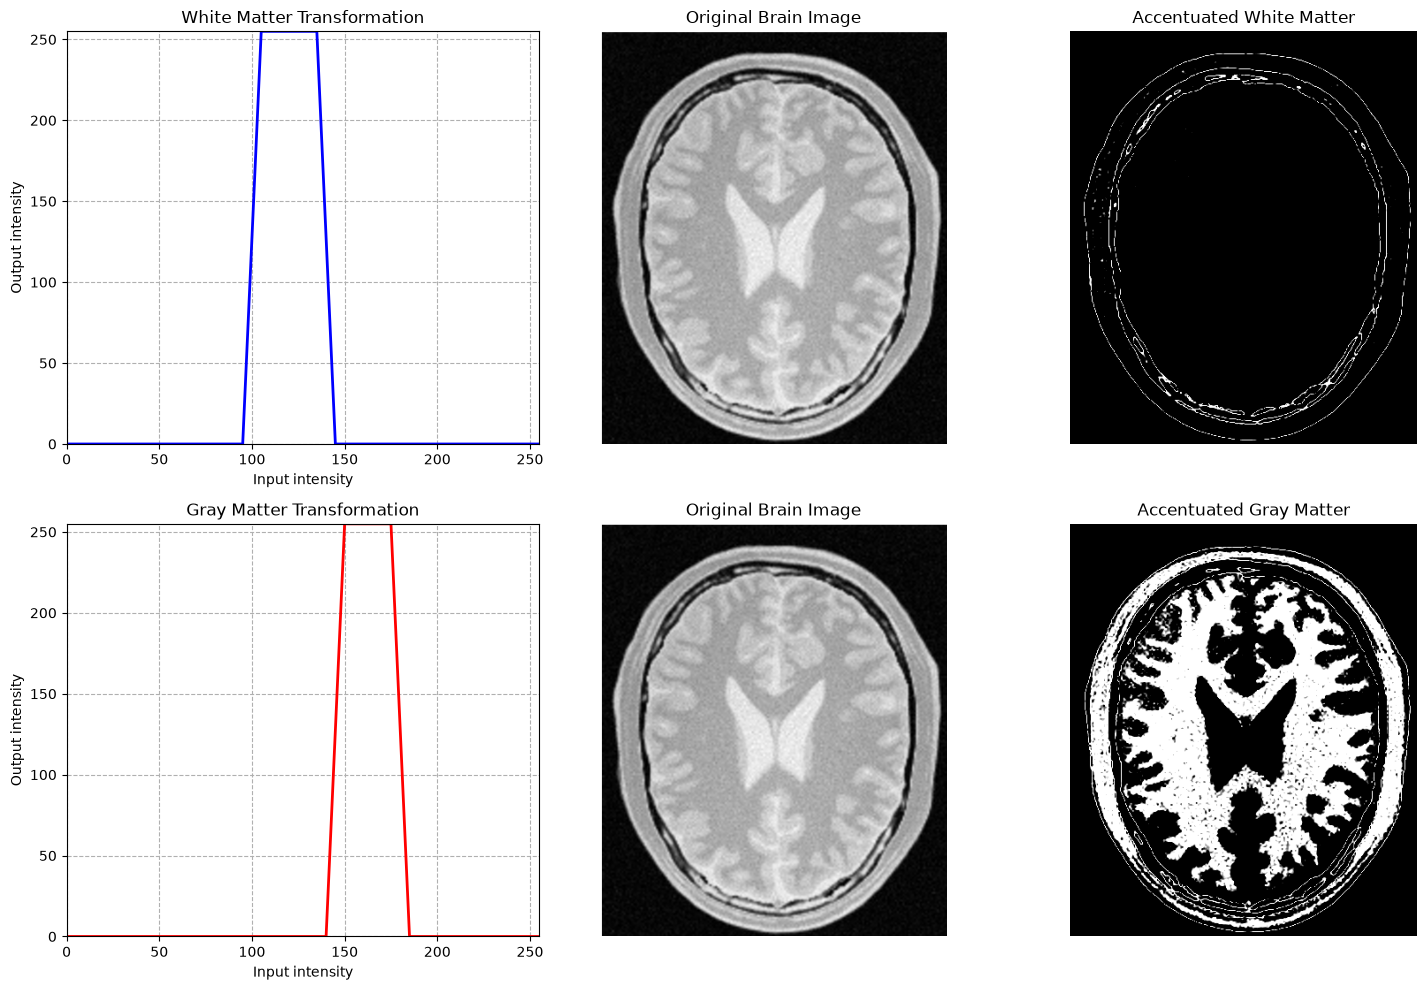

In [20]:
# 1. Define Breakpoints for Windowing
bp_white_matter = [
    [0, 0],
    [95, 0],
    [105, 255],
    [135, 255],
    [145, 0],
    [255, 0]
]

bp_gray_matter = [
    [0, 0],
    [140, 0],
    [150, 255],
    [175, 255],
    [185, 0],
    [255, 0]
]

# 2. Load the Brain Image
brain_img = cv2.imread('brain.png', cv2.IMREAD_GRAYSCALE)

if brain_img is None:
    print("Error: Could not load the brain image.")
else:
    # 3. Apply the transformations
    wm_img = intensity_transform(brain_img, bp_white_matter)
    gm_img = intensity_transform(brain_img, bp_gray_matter)
    
    # 4. Plotting
    fig, axs = plt.subplots(2, 3, figsize=(15, 10))
    x_vals = np.arange(256)
    
    # --- ROW 1: White Matter ---
    wm_arr = np.array(bp_white_matter)
    wm_lut = np.interp(x_vals, wm_arr[:,0], wm_arr[:,1])
    
    axs[0, 0].plot(x_vals, wm_lut, color='blue', linewidth=2)
    axs[0, 0].set_title('White Matter Transformation')
    axs[0, 0].set_xlabel('Input intensity')
    axs[0, 0].set_ylabel('Output intensity')
    axs[0, 0].set_xlim([0, 255])
    axs[0, 0].set_ylim([0, 255])
    axs[0, 0].grid(True, linestyle='--')
    
    axs[0, 1].imshow(brain_img, cmap='gray', vmin=0, vmax=255)
    axs[0, 1].set_title('Original Brain Image')
    axs[0, 1].axis('off')
    
    axs[0, 2].imshow(wm_img, cmap='gray', vmin=0, vmax=255)
    axs[0, 2].set_title('Accentuated White Matter')
    axs[0, 2].axis('off')
    
    # --- ROW 2: Gray Matter ---
    gm_arr = np.array(bp_gray_matter)
    gm_lut = np.interp(x_vals, gm_arr[:,0], gm_arr[:,1])
    
    axs[1, 0].plot(x_vals, gm_lut, color='red', linewidth=2)
    axs[1, 0].set_title('Gray Matter Transformation')
    axs[1, 0].set_xlabel('Input intensity')
    axs[1, 0].set_ylabel('Output intensity')
    axs[1, 0].set_xlim([0, 255])
    axs[1, 0].set_ylim([0, 255])
    axs[1, 0].grid(True, linestyle='--')
    
    axs[1, 1].imshow(brain_img, cmap='gray', vmin=0, vmax=255)
    axs[1, 1].set_title('Original Brain Image')
    axs[1, 1].axis('off')
    
    axs[1, 2].imshow(gm_img, cmap='gray', vmin=0, vmax=255)
    axs[1, 2].set_title('Accentuated Gray Matter')
    axs[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()